# Kernel Model with Triangular and Square Kernels

Short version of `kernel_model_structured.ipynb`.
It trains the pipeline with only `triangular` and `square` kernels, then generates classifier heatmaps on full images.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image as DisplayImage, display
from PIL import Image

from kernel_model.config import (
    KernelBankConfig,
    PatchExtractionConfig,
    PipelineConfig,
    SelectionConfig,
    SubsetSearchConfig,
    TrainingConfig,
)
from kernel_model.pipeline import run_pipeline
from kernel_model.responses import compute_responses


## Configure

`run_extraction=False` expects patches under `data/patches`.
Switch it to `True` if you want to regenerate them from the TIFF folders.
This notebook uses `signed_max` responses with patch standardization so triangle and square shape differences affect the learned features.


In [2]:
cfg = PipelineConfig(
    data=PatchExtractionConfig(
        healthy_dir=Path('data/TIFF Images/Normal'),
        malignant_dir=Path('data/TIFF Images/Malignant'),
        annotation_dir=Path('data/TIFF Images/malignantAnnotation'),
        output_dir=Path('data/patches'),
        patch_size=128,
        n_inside_per_image=40,
        n_outside_per_image=10,
        red_threshold=150,
        max_tries=250,
        min_nonzero_frac=0.35,
        run_extraction=False,
    ),
    bank=KernelBankConfig(
        families=('triangular', 'square'),
        n_per_family=250,
        kernel_size=31,
        sampling_method='random',
        sampling_seed=42,
    ),
    selection=SelectionConfig(
        method='mmr',
        response_fn='signed_max',
        topM=120,
        K=12,
        plot_top_kernels=12,
        standardize_responses=True,
    ),
    training=TrainingConfig(
        model_type='logistic',
        epochs=40,
        batch_size=64,
        lr=5e-4,
        rotation_aug=False,
    ),
    subset=SubsetSearchConfig(
        pair_corr_threshold=0.2,
        triple_corr_threshold=0.3,
    ),
    data_root=Path('data/patches'),
    out_dir=Path('results/triangular_square_shape_sensitive'),
    max_per_class=2500,
    resize_patch_size=128,
)
cfg


PipelineConfig(data=PatchExtractionConfig(healthy_dir=PosixPath('data/TIFF Images/Normal'), malignant_dir=PosixPath('data/TIFF Images/Malignant'), annotation_dir=PosixPath('data/TIFF Images/malignantAnnotation'), output_dir=PosixPath('data/patches'), patch_size=128, n_inside_per_image=40, n_outside_per_image=10, red_threshold=150, max_tries=250, min_pos_coverage=0.8, max_neg_coverage=0.02, near_neg_fraction=0.2, near_neg_radius=None, far_neg_radius=None, use_bbox_for_positives=False, min_nonzero_frac=0.35, min_intensity_rel=0.0, split_patients=True, train_frac=0.7, val_frac=0.15, test_frac=0.15, split_seed=42, run_extraction=False), bank=KernelBankConfig(families=('triangular', 'square'), n_per_family=250, kernel_size=31, sampling_method='random', sampling_seed=42, sampling_qmc_scramble=True), selection=SelectionConfig(method='mmr', response_fn='signed_max', topM=120, K=12, lambda_mm=0.75, plot_top_kernels=12, standardize_responses=True), training=TrainingConfig(epochs=40, batch_size=6

In [3]:
result = run_pipeline(cfg)

{
    'out_dir': str(result['out_dir']),
    'selected_kernels': len(result['selected_idxs']),
    'train_val_auc': result['clf']['auc'],
    'train_val_acc': result['clf']['acc'],
    'eval_results': result['eval_results'],
}


2026-04-02 13:32:39,329 [INFO] Starting pipeline. Output: results/triangular_square_shape_sensitive/exp_001 Device: cuda Selection: mmr
2026-04-02 13:32:42,380 [INFO] Loaded train split: Xin=2500 Xout=2500 resize=128 (patients in=61 out=236)
2026-04-02 13:32:43,112 [INFO] Loaded val split: Xin=1080 Xout=790 resize=128 (patients in=26 out=73)
2026-04-02 13:32:43,846 [INFO] Loaded test split: Xin=1040 Xout=830 resize=128 (patients in=26 out=73)
2026-04-02 13:32:43,893 [INFO] Built kernel bank: 500 kernels (sampling=random seed=42)
Kernels: 100%|██████████| 500/500 [03:59<00:00,  2.09it/s]
2026-04-02 13:36:44,744 [INFO] Patient-level grouping enabled (257 unique ids)
2026-04-02 13:36:46,419 [INFO] MMR selected kernels (bank idx): [175, 81, 225, 196, 52, 125, 218, 131, 234, 340, 221, 235]
2026-04-02 13:36:52,129 [INFO] Classifier results: AUC=0.7610 ACC=0.6915
Kernels: 100%|██████████| 500/500 [00:58<00:00,  8.58it/s]
2026-04-02 13:37:51,050 [INFO] Eval val: AUC=0.7407 ACC=0.6631
Kernels: 

{'out_dir': 'results/triangular_square_shape_sensitive/exp_001',
 'selected_kernels': 12,
 'train_val_auc': 0.7610275761973876,
 'train_val_acc': 0.6915254237288135,
 'eval_results': {'val': {'auc': 0.7406985466479137,
   'acc': 0.6631016042780749,
   'n': 1870,
   'n_pos': 1080,
   'n_neg': 790},
  'test': {'auc': 0.8108897126969415,
   'acc': 0.7358288770053476,
   'n': 1870,
   'n_pos': 1040,
   'n_neg': 830}}}

results/triangular_square_shape_sensitive/exp_001/clf_roc_pr.png


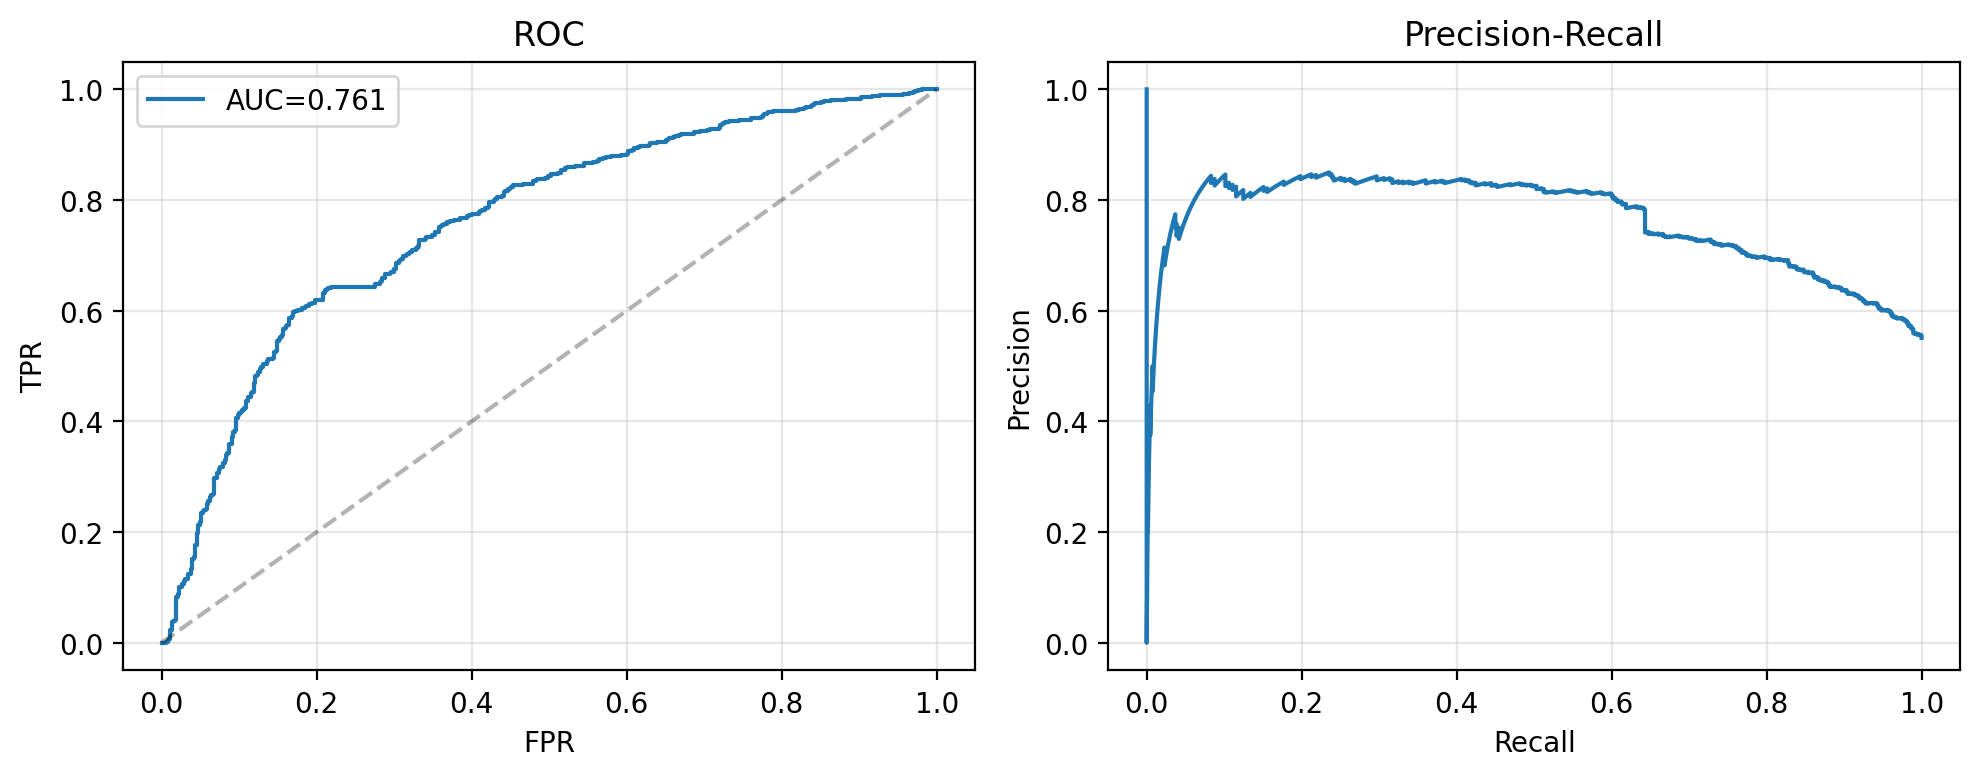

results/triangular_square_shape_sensitive/exp_001/confusion.png


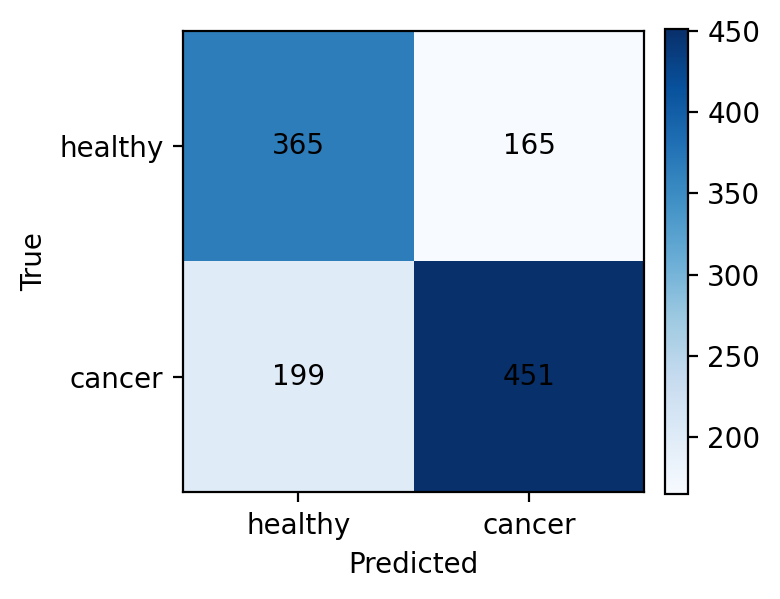

results/triangular_square_shape_sensitive/exp_001/scatter_best_pair.png


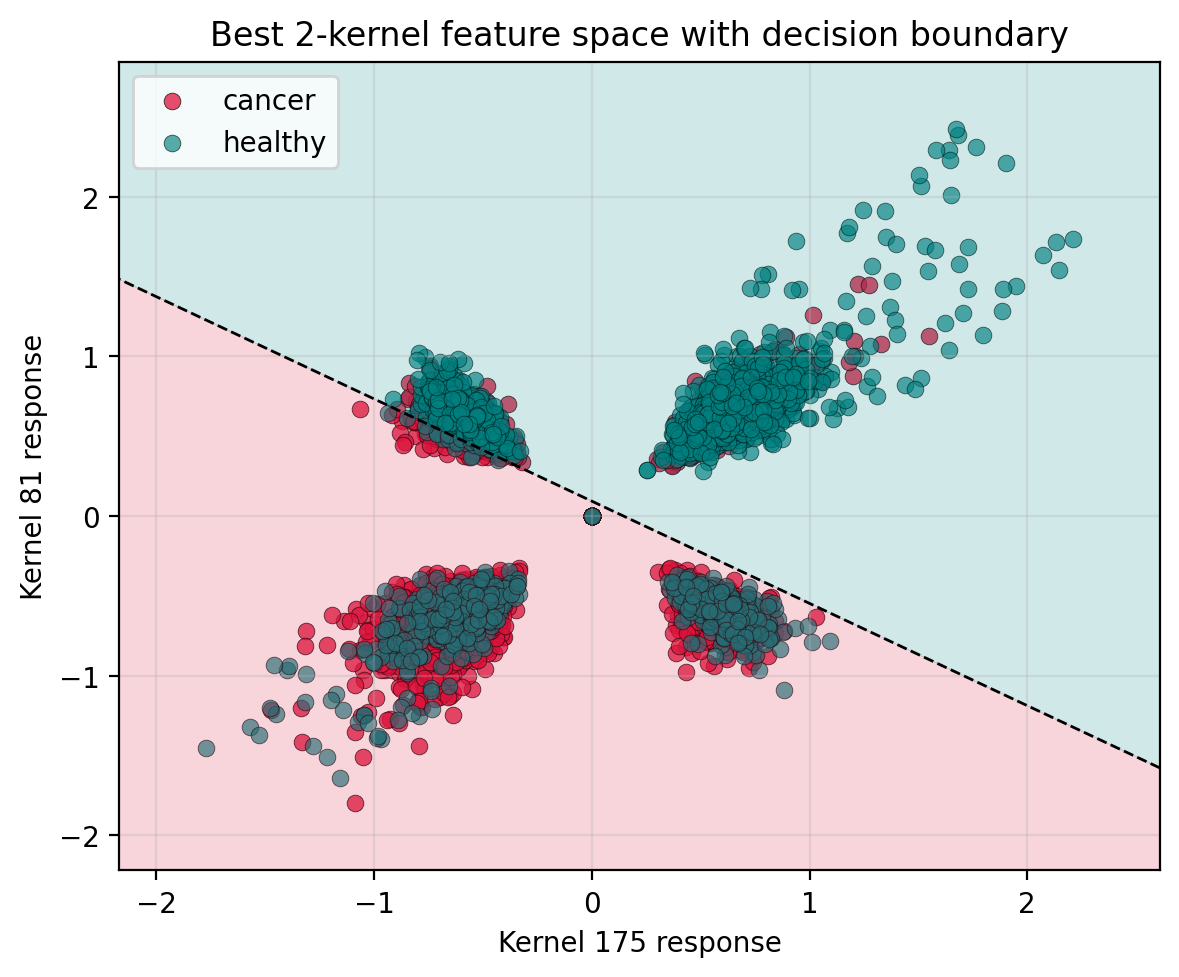

results/triangular_square_shape_sensitive/exp_001/scatter_best_triple.png


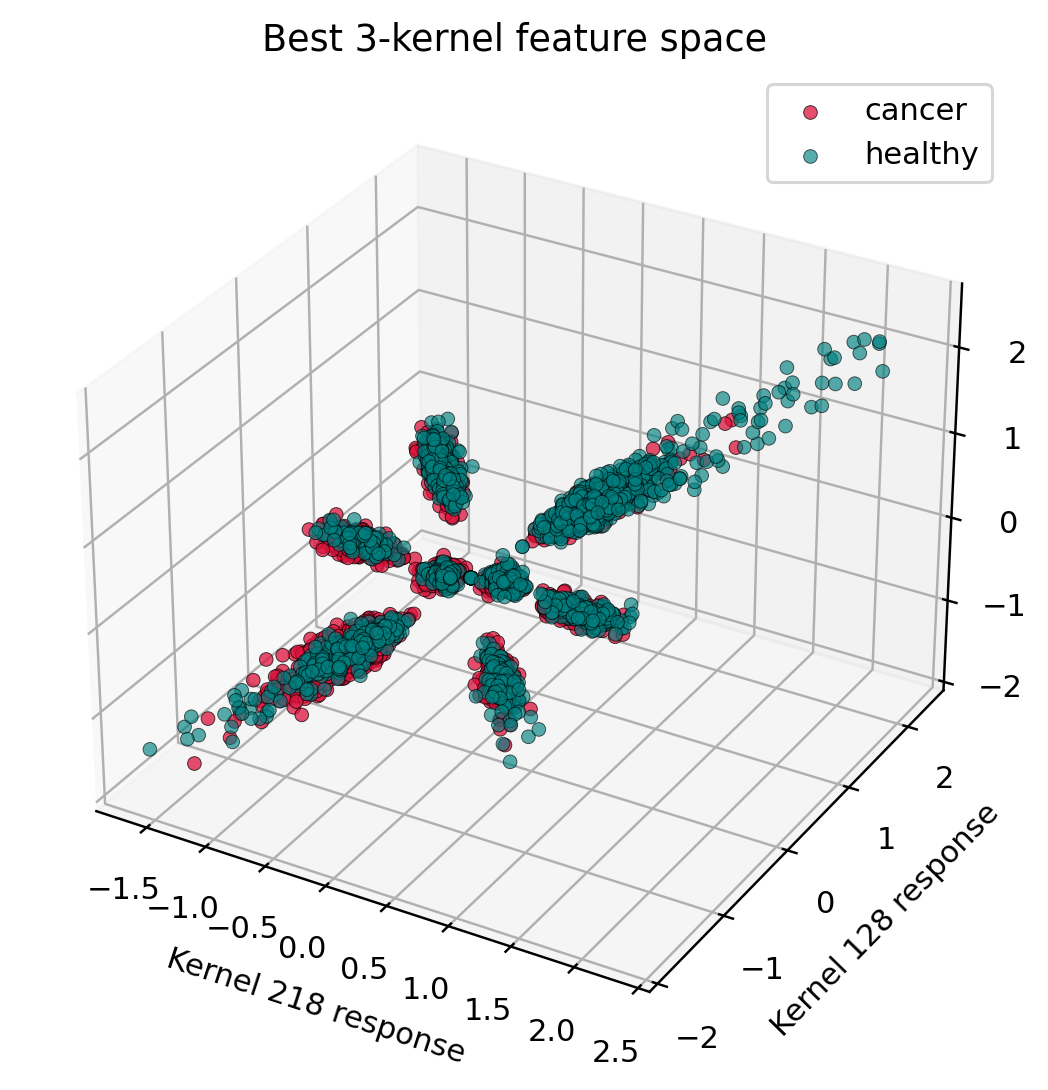

/tmp/ipykernel_88705/1973556372.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


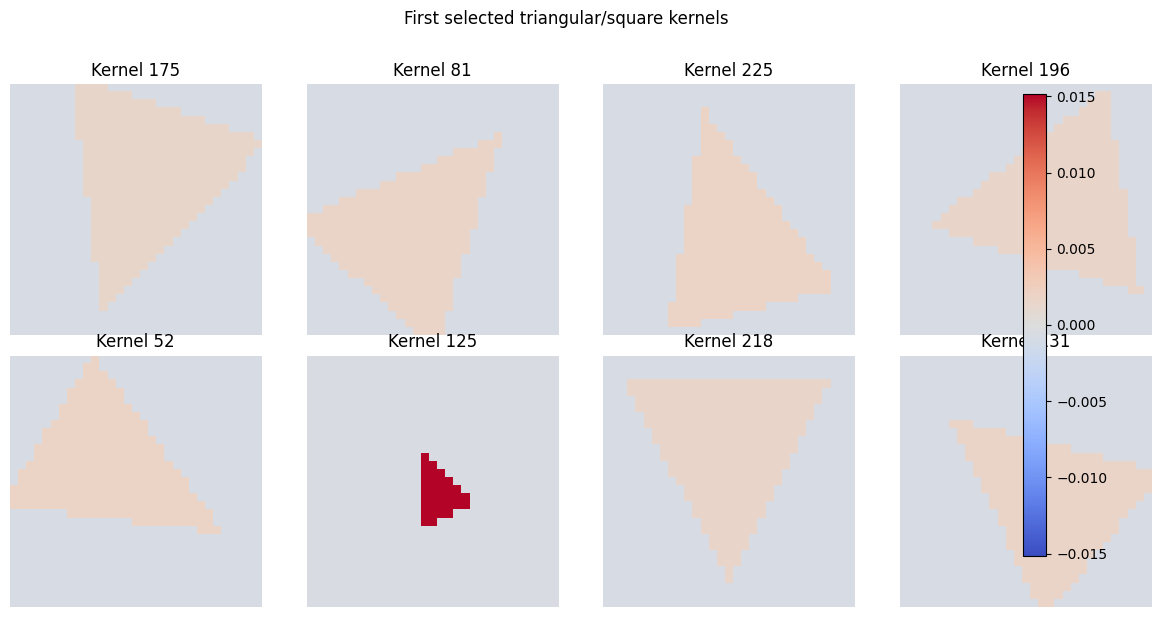

In [4]:
out_dir = Path(result['out_dir'])

artifact_names = [
    'clf_roc_pr.png',
    'confusion.png',
    'scatter_best_pair.png',
    'scatter_best_triple.png',
]

for name in artifact_names:
    path = out_dir / name
    if path.exists():
        print(path)
        display(DisplayImage(filename=str(path)))

kernels = np.load(out_dir / 'kernels.npy').astype(np.float32)
selected_idxs = np.array(result['selected_idxs'], dtype=int)
selected_kernels = kernels[selected_idxs[: min(8, len(selected_idxs))]]

if len(selected_kernels) > 0:
    cols = min(4, len(selected_kernels))
    rows = int(np.ceil(len(selected_kernels) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 3.0 * rows))
    axes = np.array(axes).reshape(rows, cols)
    vmax = np.max(np.abs(selected_kernels)) + 1e-12
    for i in range(rows * cols):
        ax = axes.flat[i]
        ax.axis('off')
        if i >= len(selected_kernels):
            continue
        im = ax.imshow(selected_kernels[i], cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.set_title(f'Kernel {selected_idxs[i]}')
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    fig.suptitle('First selected triangular/square kernels', y=1.02)
    fig.tight_layout()
    plt.show()


## Heatmaps

Run this after training. It slides the trained classifier over full TIFF images and saves overlays to
`result['out_dir'] / 'heatmaps'` and side-by-side previews to `result['out_dir'] / 'heatmaps_pairs'`.


In [5]:
image_ids = ['IMG015', 'IMG044', 'IMG059', 'IMG330']
stride = None  # None -> patch_size // 4
show = False

model = result['clf']['model']
if model is None:
    raise RuntimeError('No model found in result. Run the training cell first.')

model.eval()
model_device = next(model.parameters()).device
out_dir = Path(result['out_dir'])
heatmap_dir = out_dir / 'heatmaps'
pair_dir = out_dir / 'heatmaps_pairs'
heatmap_dir.mkdir(exist_ok=True)
pair_dir.mkdir(exist_ok=True)

kernels = np.load(out_dir / 'kernels.npy').astype(np.float32)
selected_idxs = np.array(result['selected_idxs'], dtype=int)
selected_kernels = kernels[selected_idxs]
bank_selected = [{'kernel': kernel} for kernel in selected_kernels]

patch_size = int(cfg.data.patch_size)
model_patch_size = int(cfg.resize_patch_size) if cfg.resize_patch_size else patch_size
stride = max(1, patch_size // 4) if stride is None else int(stride)

def grid_starts(length: int, patch: int, step: int):
    if length < patch:
        return []
    starts = list(range(0, length - patch + 1, step))
    if starts and starts[-1] != length - patch:
        starts.append(length - patch)
    return starts

def find_image_path(img_id: str) -> Path:
    normal_path = Path('data/TIFF Images/Normal') / f'{img_id}.tif'
    malignant_path = Path('data/TIFF Images/Malignant') / f'{img_id}.tif'
    if normal_path.exists():
        return normal_path
    if malignant_path.exists():
        return malignant_path
    raise FileNotFoundError(f'{img_id}.tif not found in Normal or Malignant folders.')

generated = []
for img_id in image_ids:
    img_path = find_image_path(img_id)
    img = Image.open(img_path).convert('L')
    img_arr = np.array(img, dtype=np.float32) / 255.0
    height, width = img_arr.shape

    ys = grid_starts(height, patch_size, stride)
    xs = grid_starts(width, patch_size, stride)
    if not ys or not xs:
        raise ValueError(f'Image {img_id} is smaller than patch size {patch_size}.')

    patches = []
    coords = []
    for y in ys:
        for x in xs:
            patch = img_arr[y:y + patch_size, x:x + patch_size]
            if model_patch_size != patch_size:
                patch = np.array(
                    Image.fromarray((patch * 255).astype(np.uint8)).resize(
                        (model_patch_size, model_patch_size),
                        Image.BILINEAR,
                    ),
                    dtype=np.float32,
                ) / 255.0
            patches.append(patch)
            coords.append((y, x))
    patches = np.stack(patches, axis=0).astype(np.float32)

    empty = np.zeros((0, patches.shape[1], patches.shape[2]), dtype=np.float32)
    responses = compute_responses(
        bank_selected,
        patches,
        empty,
        device=model_device,
        batch_size=cfg.training.batch_size,
        response_fn=cfg.selection.response_fn,
        standardize_patches=cfg.selection.standardize_responses,
    )
    X_feat = np.stack([entry['r_in'] for entry in responses], axis=1)

    if result['clf'].get('standardize') and result['clf'].get('mean') is not None and result['clf'].get('std') is not None:
        X_feat = (X_feat - result['clf']['mean']) / result['clf']['std']

    with torch.no_grad():
        logits = model(torch.from_numpy(X_feat).float().to(model_device))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

    heatmap = np.zeros((height, width), dtype=np.float32)
    counts = np.zeros((height, width), dtype=np.float32)
    for (y, x), prob in zip(coords, probs):
        heatmap[y:y + patch_size, x:x + patch_size] += prob
        counts[y:y + patch_size, x:x + patch_size] += 1.0
    heatmap = heatmap / np.maximum(counts, 1.0)

    heatmap_path = heatmap_dir / f'{img_id}_heatmap.png'
    plt.figure(figsize=(7, 7))
    plt.imshow(img_arr, cmap='gray')
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.colorbar(label='Cancer probability')
    plt.title(f'Heatmap | {img_path.name} | max={probs.max():.3f} mean={probs.mean():.3f}')
    plt.axis('off')
    plt.savefig(heatmap_path, dpi=200, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close()

    original_rgb = Image.open(img_path).convert('RGB')
    heat_rgb = Image.open(heatmap_path).convert('RGB')
    if original_rgb.height != heat_rgb.height:
        new_width = int(original_rgb.width * heat_rgb.height / original_rgb.height)
        original_rgb = original_rgb.resize((new_width, heat_rgb.height), Image.BILINEAR)

    pair = Image.new('RGB', (original_rgb.width + heat_rgb.width, heat_rgb.height))
    pair.paste(original_rgb, (0, 0))
    pair.paste(heat_rgb, (original_rgb.width, 0))
    pair_path = pair_dir / f'{img_id}_pair.png'
    pair.save(pair_path)
    generated.append(pair_path)

generated


Kernels: 100%|██████████| 12/12 [00:18<00:00,  1.52s/it]


[PosixPath('results/triangular_square_shape_sensitive/exp_001/heatmaps_pairs/IMG015_pair.png'),
 PosixPath('results/triangular_square_shape_sensitive/exp_001/heatmaps_pairs/IMG044_pair.png'),
 PosixPath('results/triangular_square_shape_sensitive/exp_001/heatmaps_pairs/IMG059_pair.png'),
 PosixPath('results/triangular_square_shape_sensitive/exp_001/heatmaps_pairs/IMG330_pair.png')]

results/triangular_square_shape_sensitive/exp_001/heatmaps_pairs/IMG015_pair.png


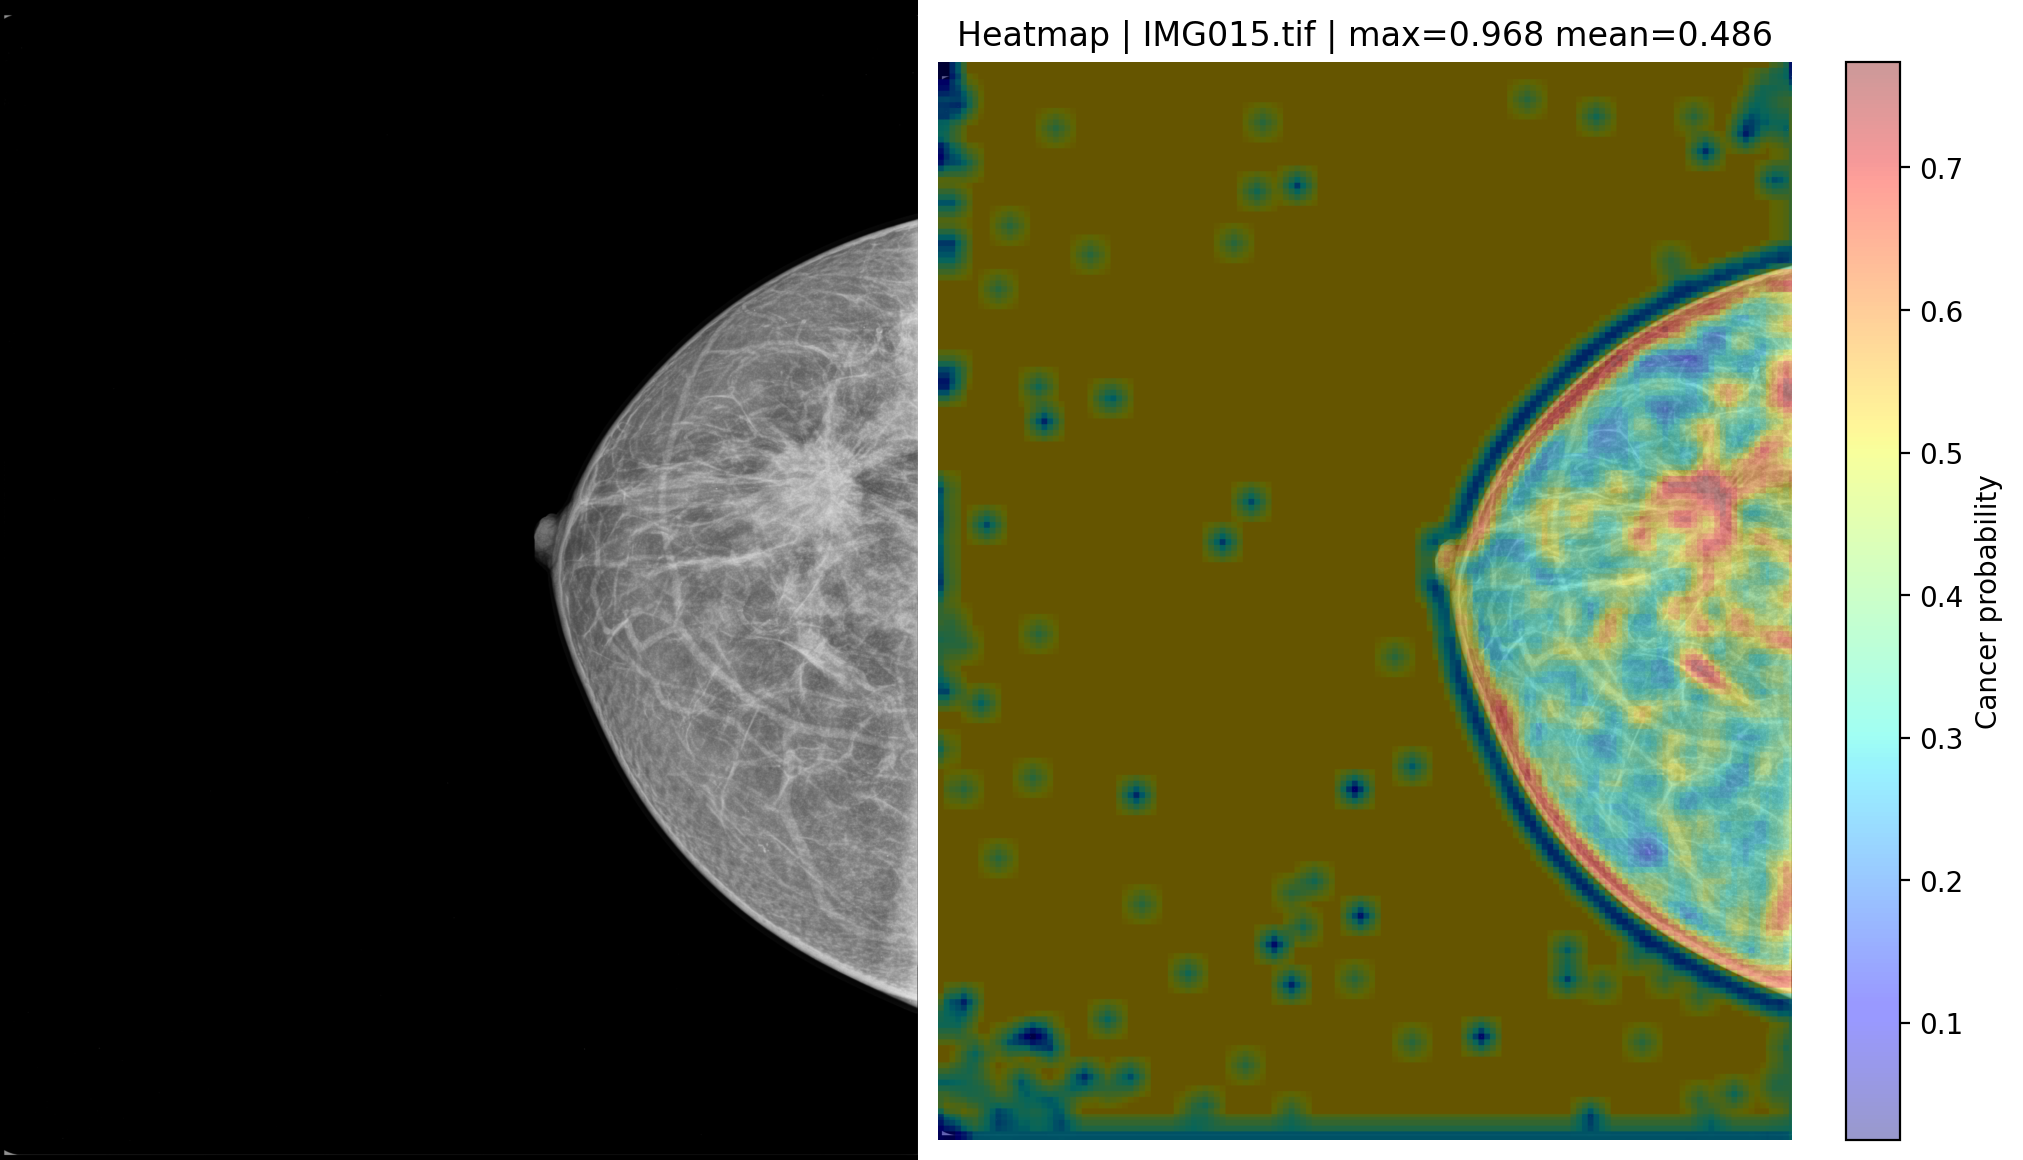

results/triangular_square_shape_sensitive/exp_001/heatmaps_pairs/IMG044_pair.png


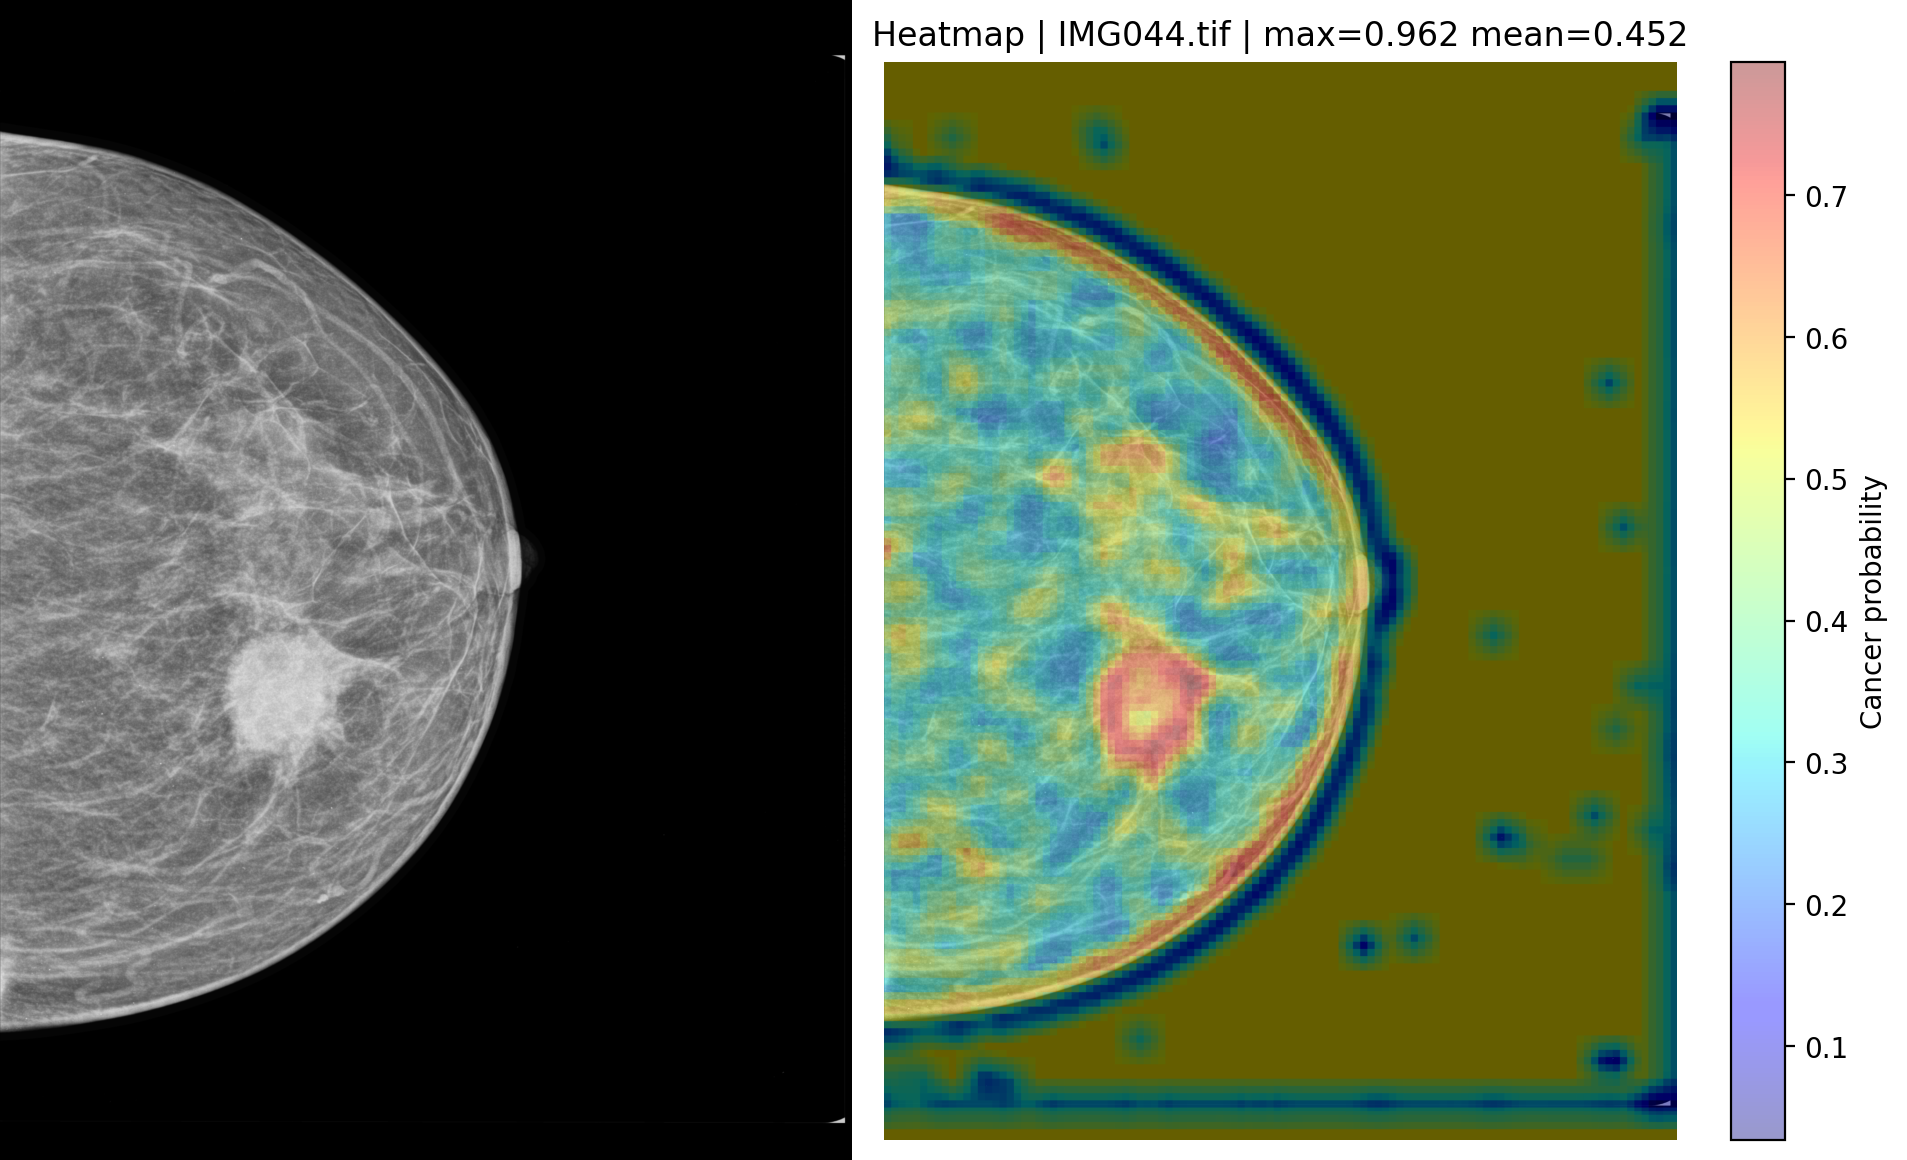

results/triangular_square_shape_sensitive/exp_001/heatmaps_pairs/IMG059_pair.png


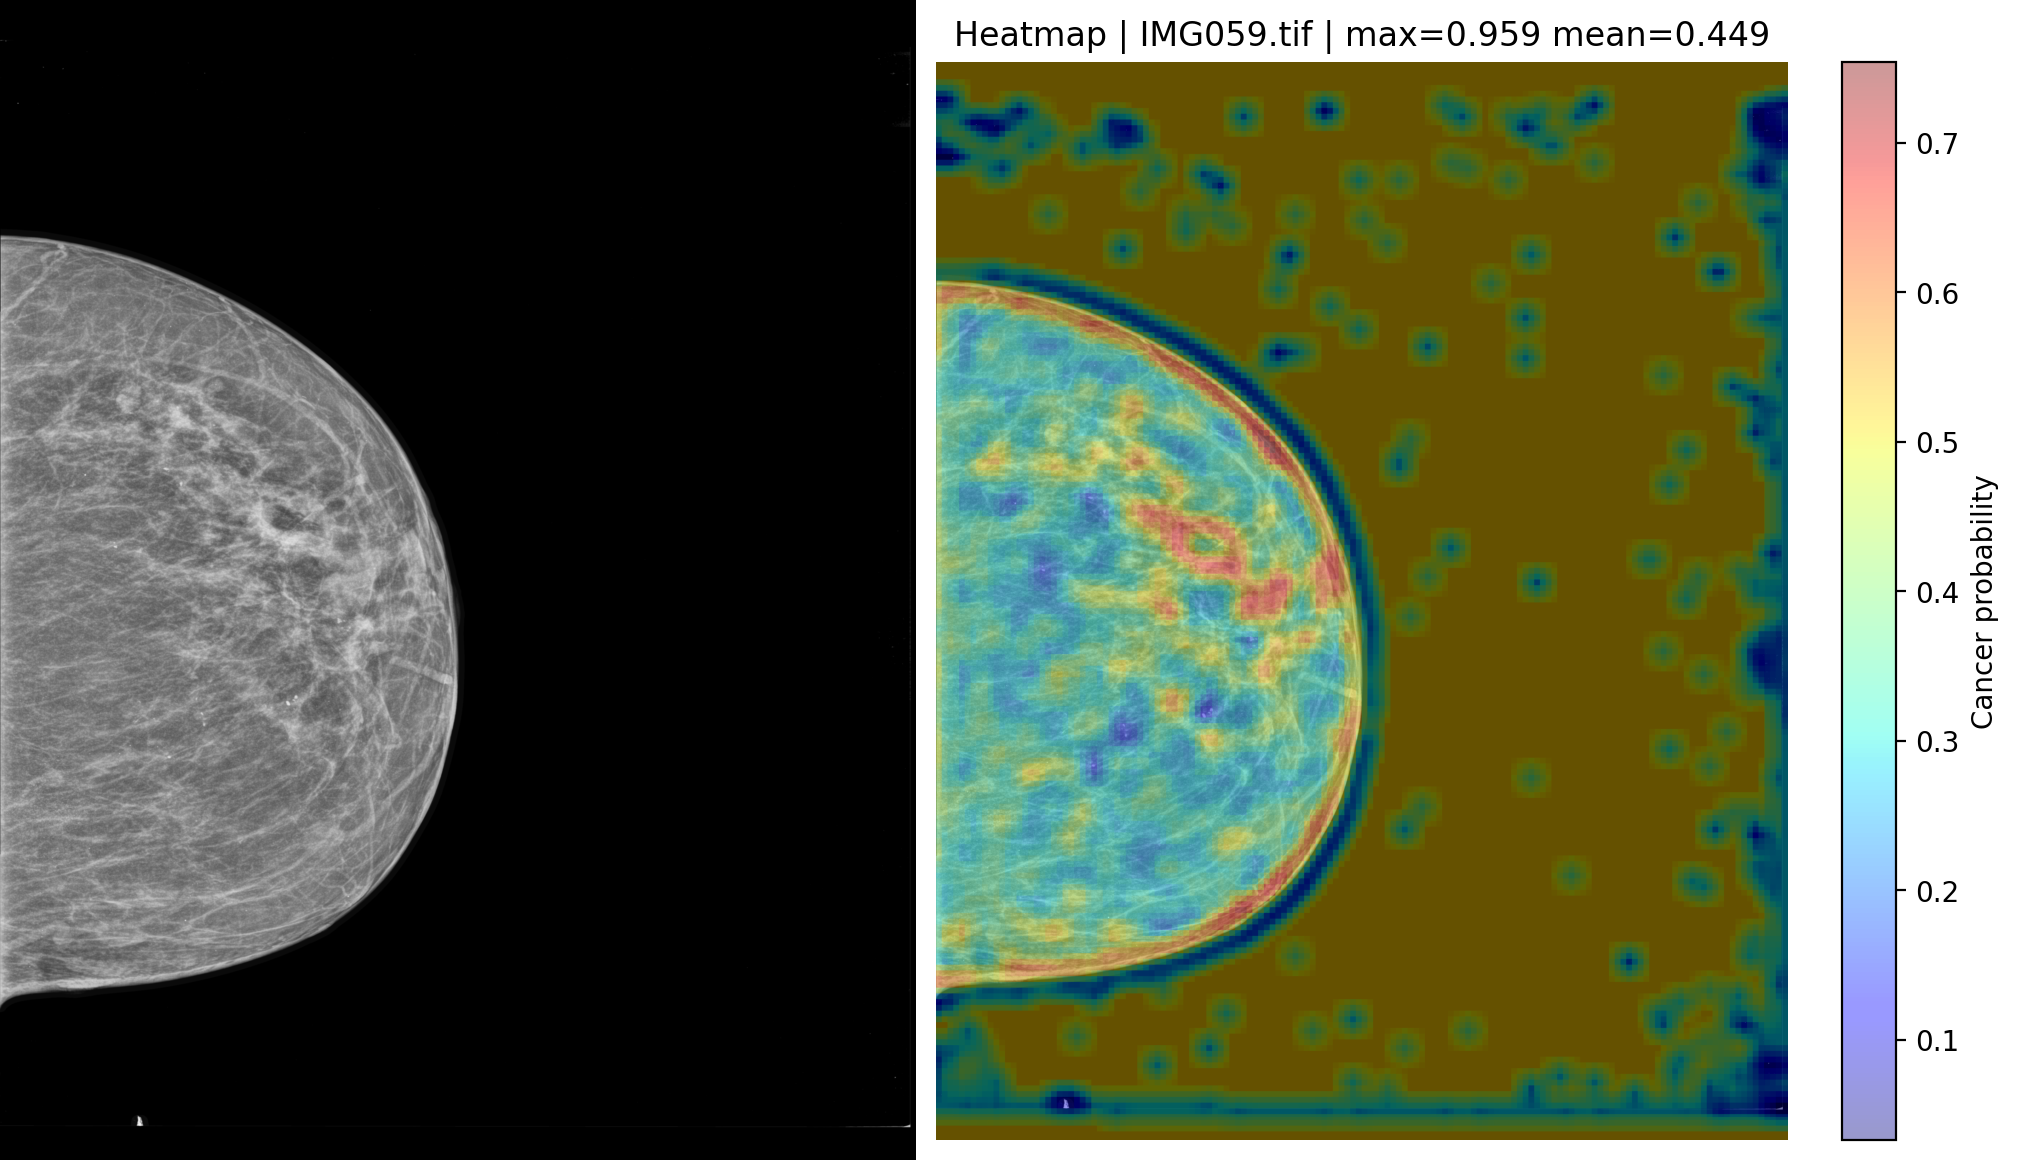

results/triangular_square_shape_sensitive/exp_001/heatmaps_pairs/IMG330_pair.png


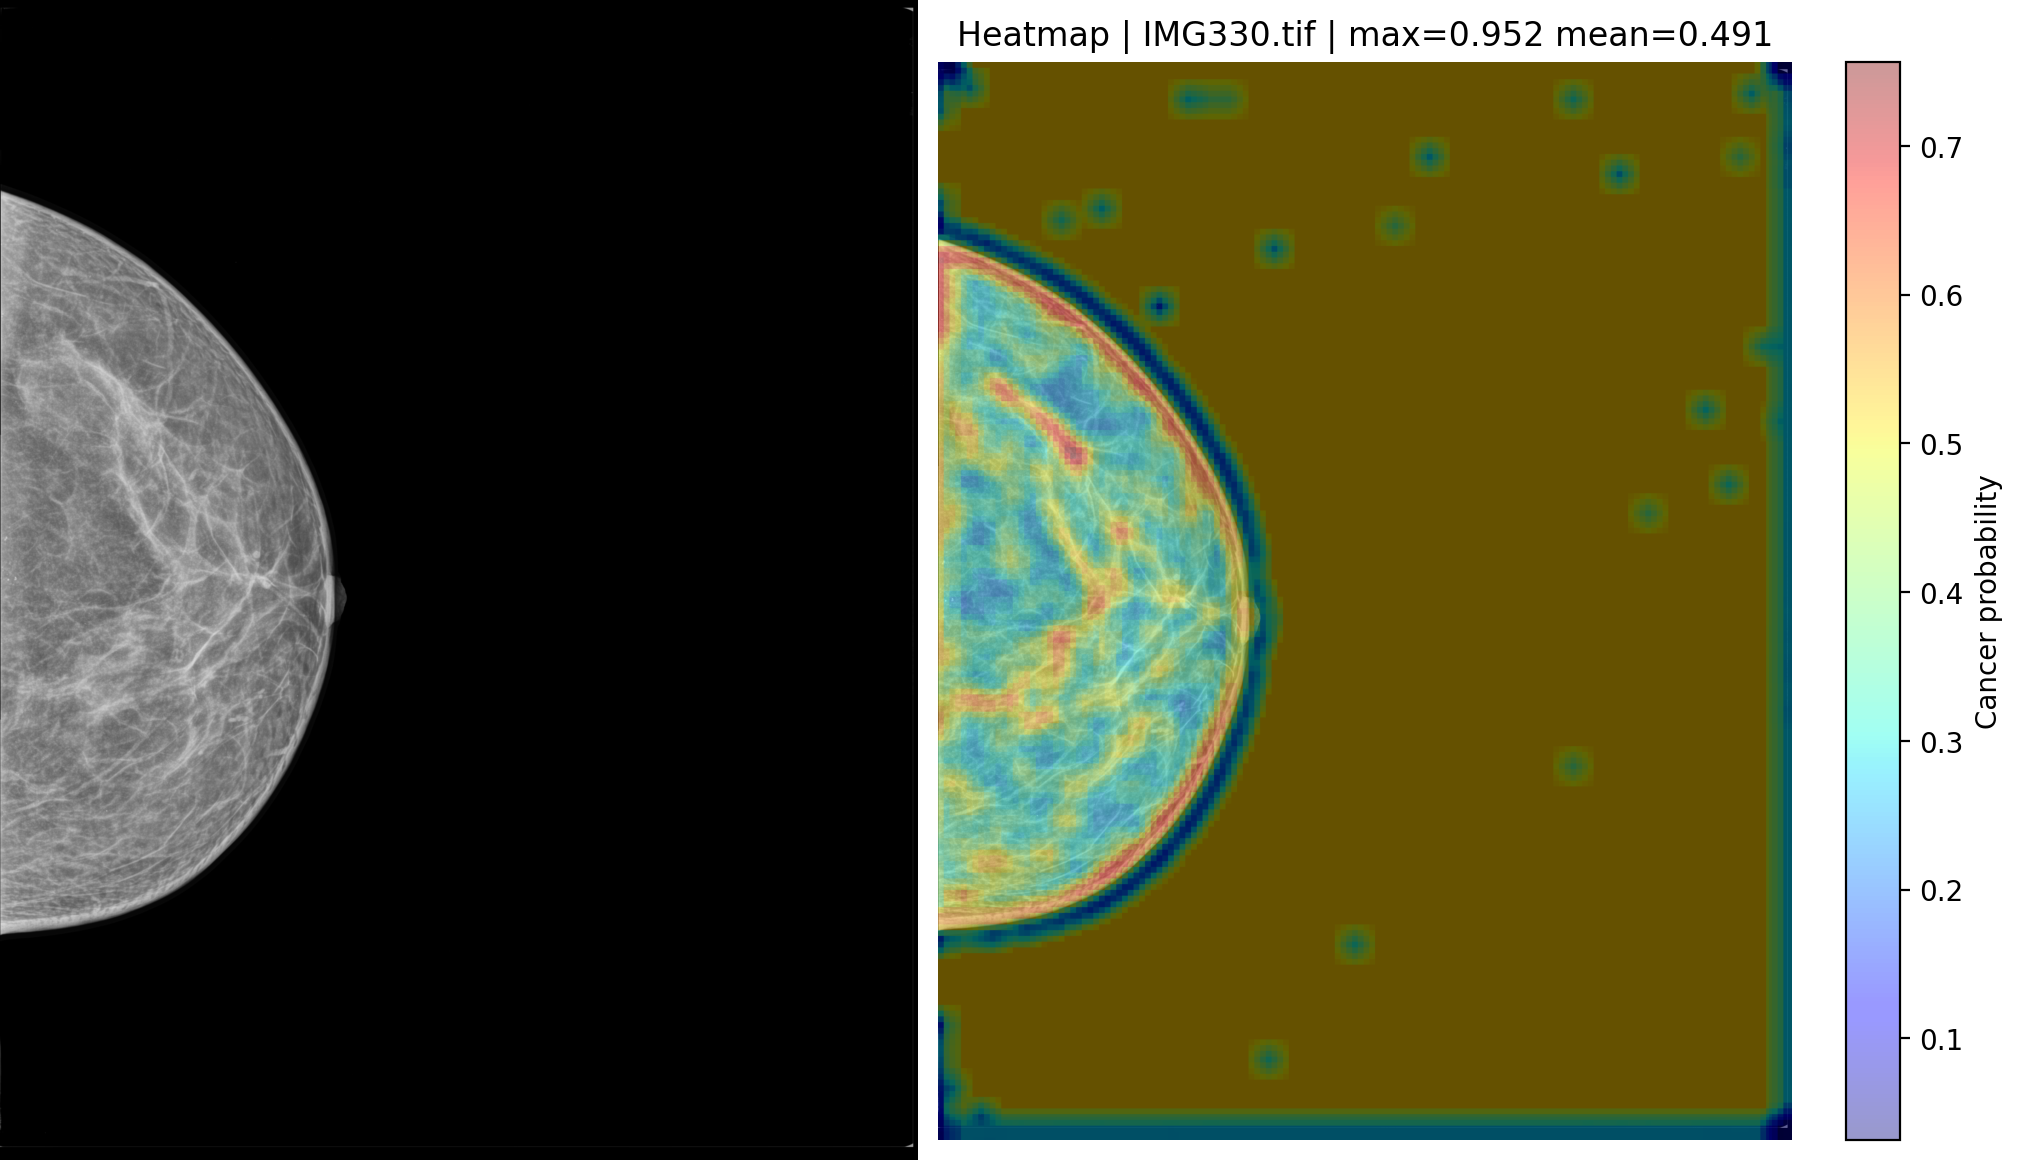

In [6]:
for img_id in image_ids:
    pair_path = Path(result['out_dir']) / 'heatmaps_pairs' / f'{img_id}_pair.png'
    if pair_path.exists():
        print(pair_path)
        display(DisplayImage(filename=str(pair_path)))
